loading the data

In [1]:
import pandas as pd
df=pd.read_csv("IPL.csv",low_memory=False)
print(df.shape)
print(df.head())


(295732, 64)
   match_id        date match_type             event_name  innings  \
0    335982  2008-04-18        T20  Indian Premier League        1   
1    335982  2008-04-18        T20  Indian Premier League        1   
2    335982  2008-04-18        T20  Indian Premier League        1   
3    335982  2008-04-18        T20  Indian Premier League        1   
4    335982  2008-04-18        T20  Indian Premier League        1   

            batting_team                 bowling_team  over  ball  ball_no  \
0  Kolkata Knight Riders  Royal Challengers Bangalore     0     1      0.1   
1  Kolkata Knight Riders  Royal Challengers Bangalore     0     2      0.2   
2  Kolkata Knight Riders  Royal Challengers Bangalore     0     3      0.3   
3  Kolkata Knight Riders  Royal Challengers Bangalore     0     3      0.3   
4  Kolkata Knight Riders  Royal Challengers Bangalore     0     4      0.4   

   ... team_balls  team_wicket  new_batter  power_surge_start batter_runs  \
0  ...          1   

In [2]:
print(df.columns.tolist())

['match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'striker_out', 'next_batter']


top 10 run scorers

In [ ]:
top_batsmen = (
    df.groupby("batter")["runs_batter"].sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_batsmen)

batter
V Kohli           9346
RG Sharma         7331
S Dhawan          6769
DA Warner         6567
KL Rahul          5828
SK Raina          5536
MS Dhoni          5439
AM Rahane         5367
AB de Villiers    5181
SV Samson         5181
Name: runs_batter, dtype: int64


top 10 bowlers by economy rate

In [4]:
bowler_stats = df.groupby("bowler").agg(
    legal_balls=("valid_ball", "sum"),
    runs_conceded=("runs_bowler", "sum")
)
bowler_stats["economy_rate"] = (bowler_stats["runs_conceded"] / bowler_stats["legal_balls"]) * 6

qualified_bowlers = bowler_stats[bowler_stats["legal_balls"] >= 300]
top_bowlers = qualified_bowlers.sort_values("economy_rate").head(10)
print(top_bowlers)

                  legal_balls  runs_conceded  economy_rate
bowler                                                    
A Kumble                  965           1058      6.578238
GD McGrath                324            357      6.611111
M Muralitharan           1528           1706      6.698953
RE van der Merwe          443            498      6.744921
DL Vettori                777            879      6.787645
SP Narine                4660           5273      6.789270
J Yadav                   390            445      6.846154
J Botha                   694            800      6.916427
AD Mascarenhas            308            356      6.935065
DW Steyn                 2182           2523      6.937672


bar chart of top scorers

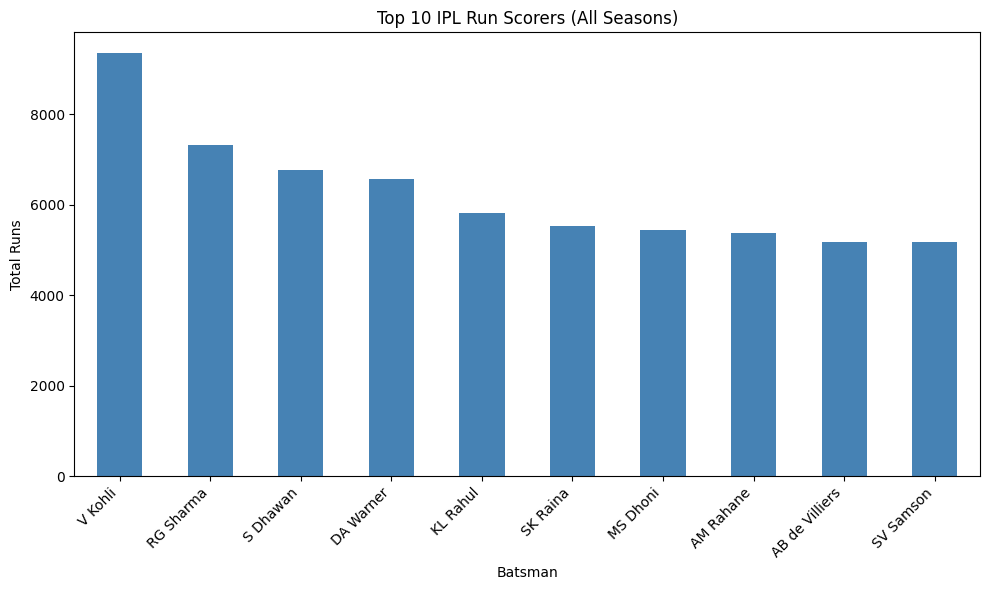

In [5]:
import matplotlib.pyplot as plt

top_batsmen.plot(kind="bar", color="steelblue", figsize=(10,6))
plt.title("Top 10 IPL Run Scorers (All Seasons)")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

runs scored per ball(powerplay vs death overs)

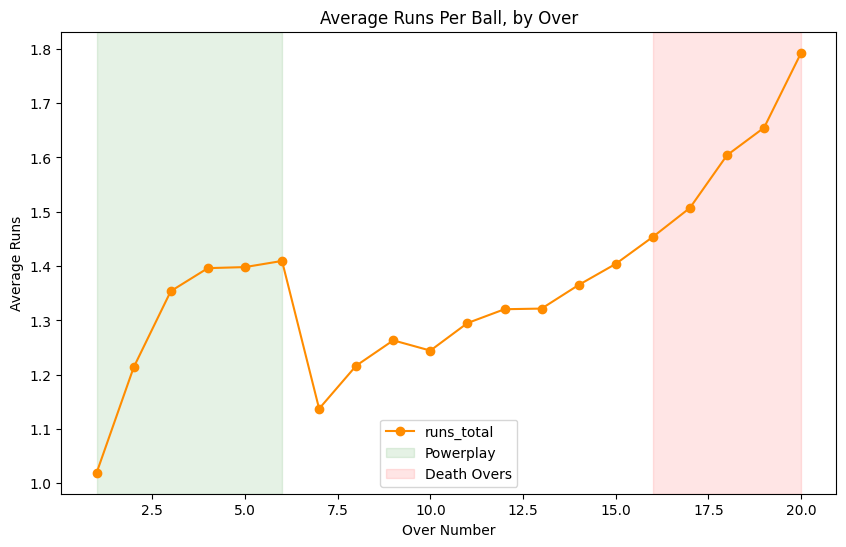

In [6]:
runs_per_over = df.groupby("over")["runs_total"].mean()
runs_per_over.index = runs_per_over.index + 1  # overs are 0-indexed in this file

runs_per_over.plot(kind="line", marker="o", color="darkorange", figsize=(10,6))
plt.title("Average Runs Per Ball, by Over")
plt.xlabel("Over Number")
plt.ylabel("Average Runs")
plt.axvspan(1, 6, alpha=0.1, color="green", label="Powerplay")
plt.axvspan(16, 20, alpha=0.1, color="red", label="Death Overs")
plt.legend()
plt.show()

does winning the toss help win the match?

In [8]:
matches = df.drop_duplicates(subset="match_id")[
    ["match_id", "toss_winner", "match_won_by"]
].dropna(subset=["match_won_by"])

matches["toss_helped_win"] = matches["toss_winner"] == matches["match_won_by"]
toss_win_rate = matches["toss_helped_win"].mean() * 100
print(f"Toss winner  won the match {toss_win_rate:.1f}% of the time, across {len(matches)} matches.")

Toss winner  won the match 50.5% of the time, across 1243 matches.


deep dive on one player

In [9]:
player_name = "V Kohli" 
player_balls = df[df["batter"] == player_name]

total_runs = player_balls["runs_batter"].sum()
balls_faced = len(player_balls)
strike_rate = (total_runs / balls_faced) * 100

print(f"Total runs: {total_runs}")
print(f"Balls faced: {balls_faced}")
print(f"Strike rate: {strike_rate:.2f}")

Total runs: 9346
Balls faced: 7127
Strike rate: 131.14
